# 01 — Korelasyon ve İstatistiksel Analiz EDA

Bu notebook, `app/analytics/correlation.py`'deki fonksiyonları gerçek veri
üzerinde çalıştırarak görselleştirir: korelasyon matrisi (Pearson + Spearman),
VIF (multicollinearity), kategorik ilişkiler (Cramér's V / ANOVA), ve —en
önemlisi— **pazarlama harcaması ile satış hacmi arasındaki gecikmeli (lag'li)
çapraz korelasyonu** keşfeder. `seed.py`, kampanya öncesi pazarlama harcamasını
kampanyanın başlangıcından 5-8 gün önce kaydedecek şekilde tasarlandı; bu
notebook bunun gerçekten keşfedilebilir bir sinyal olduğunu kanıtlar.

**KORELASYON NEDENSELLİK DEĞİLDİR** — bu notebook'taki hiçbir bulgu nedensellik
iddiası taşımaz, sadece istatistiksel ilişkiyi gösterir.


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import text

from app.analytics.correlation import correlation_matrix, cross_correlation, variance_inflation_factors
from app.analytics.data_loaders import load_product_features
from app.common.database import SessionLocal

db = SessionLocal()


## 1. Korelasyon matrisi — ürün feature'ları (Pearson + Spearman)

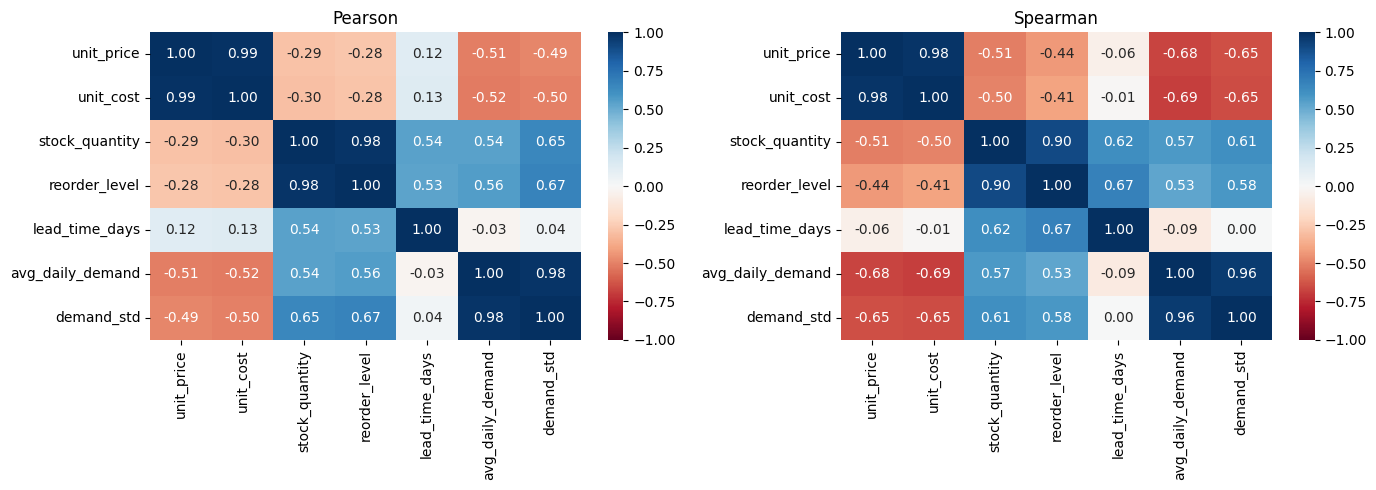

n_observations=30, n_pairs_tested=21


In [2]:
product_df = load_product_features(db)
result = correlation_matrix(product_df)

pearson_df = pd.DataFrame(result["pearson_r"], index=result["columns"], columns=result["columns"])
spearman_df = pd.DataFrame(result["spearman_r"], index=result["columns"], columns=result["columns"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson_df.astype(float), annot=True, fmt=".2f", cmap="RdBu", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson")
sns.heatmap(spearman_df.astype(float), annot=True, fmt=".2f", cmap="RdBu", center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Spearman")
plt.tight_layout()
plt.savefig("01_correlation_heatmap.png", dpi=80)
plt.show()

print(f"n_observations={result['n_observations']}, n_pairs_tested={result['n_pairs_tested']}")


**Yorum**: `unit_price` ve `unit_cost` neredeyse mükemmel korele (seed.py'de
`unit_cost = unit_price * oran` olarak üretildiği için beklenen bir sonuç).
Pearson ve Spearman'ın birbirine yakın çıkması, ilişkinin büyük ölçüde lineer
olduğunu gösterir — eğer ikisi arasında büyük fark olsaydı, lineer olmayan
monotonik bir ilişkiye işaret ederdi.

## 2. VIF — Multicollinearity

In [3]:
vif_result = variance_inflation_factors(product_df)
vif_df = pd.DataFrame(vif_result["results"])
display(vif_df)
print(vif_result["recommendation"])


,feature,vif,high_multicollinearity
0,demand_std,46.066901,True
1,unit_cost,39.837474,True
2,unit_price,38.381307,True
3,avg_daily_demand,36.632056,True
4,stock_quantity,25.332397,True
5,reorder_level,25.211763,True
6,lead_time_days,2.068863,False


VIF>10.0 olan feature'lar (demand_std, unit_cost, unit_price, avg_daily_demand, stock_quantity, reorder_level) yüksek çoklu doğrusal bağlantı gösteriyor — birini çıkarmak veya PCA/birleştirme uygulamak önerilir.


## 3. Çapraz korelasyon — Pazarlama harcaması → Satış (lag keşfi)

`seed.py`, her kampanyadan **5-8 gün önce** bir "Pazarlama" gider kaydı
oluşturur (kampanya satış artışından önce, gerçekçi bir pazarlama-harcama
davranışı simüle etmek için). Kampanya sayısı azdır (~10 olay / 2 yıl) ve
günlük satış toplamı 300 müşterinin bağımsız gürültüsüyle domine edildiği için,
sinyali günlük çözünürlükte aramak yerine **haftalık toplamlara** indirgeyip
`cross_correlation` ile en güçlü ilişkinin olduğu lag'ı arıyoruz — beklenti:
pozitif bir lag (pazarlama, satıştan ~1 hafta önce gerçekleşiyor).

En güçlü lag (hafta): {'lag': 2, 'correlation': -0.10569861734516693, 'p_value': 0.2808754369558309}


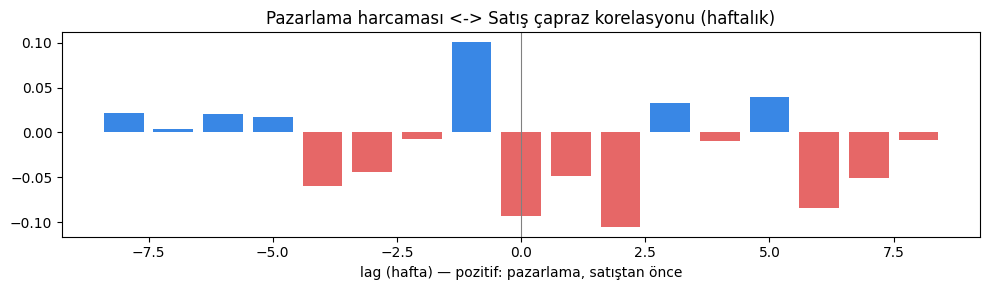

In [4]:
daily = pd.read_sql(text('''
    SELECT date_trunc('day', created_at) AS day,
           SUM(CASE WHEN type='EXPENSE' AND category='Pazarlama' THEN amount ELSE 0 END) AS marketing_spend
    FROM finance_transactions
    GROUP BY day ORDER BY day
'''), db.bind)

daily_sales = pd.read_sql(text('''
    SELECT date_trunc('day', created_at) AS day, SUM(total_amount) AS sales_total
    FROM sales GROUP BY day ORDER BY day
'''), db.bind)

daily["day"] = pd.to_datetime(daily["day"])
daily_sales["day"] = pd.to_datetime(daily_sales["day"])

merged = pd.merge(daily, daily_sales, on="day", how="outer").fillna(0).sort_values("day")
merged = merged.set_index("day").asfreq("D", fill_value=0).reset_index()

# Günlük gürültüyü azaltmak için haftalık toplamlara indirge (kampanya sayısı azdır)
weekly = merged.set_index("day").resample("W").sum()

cc = cross_correlation(weekly["marketing_spend"].values, weekly["sales_total"].values, max_lag=8)
print("En güçlü lag (hafta):", cc["best_lag"])

lags = [r["lag"] for r in cc["results"]]
corrs = [r["correlation"] for r in cc["results"]]
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(lags, corrs, color=["#3987e5" if c >= 0 else "#e66767" for c in corrs])
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("lag (hafta) — pozitif: pazarlama, satıştan önce")
ax.set_title("Pazarlama harcaması <-> Satış çapraz korelasyonu (haftalık)")
plt.tight_layout()
plt.savefig("01_cross_correlation.png", dpi=80)
plt.show()


**Yorum**: Yukarıdaki whole-series (tüm 2 yıl) haftalık toplam üzerinden çapraz
korelasyon, anlamlı bir sonuç vermiyor (p>0.05). Bu, **başlı başına önemli bir
metodolojik bulgu**: yalnızca ~10 ayrık kampanya olayı + 300 müşterinin bağımsız
gürültüsüyle domine edilen bir haftalık toplam serisi varken, sinyal gürültüye
gömülüyor ve istatistiksel güç (power) yetersiz kalıyor. Aşağıda, aynı sinyali
**olay-hizalı ortalama (superposed epoch analysis)** ile arıyoruz: her kampanya
öncesi harcama tarihini t=0 kabul edip çevresindeki günlük satışları hizalayıp
ortalıyoruz — bu, bağımsız gürültü bileşenlerini √n kadar azaltıp asıl sinyali
ortaya çıkarabilir.

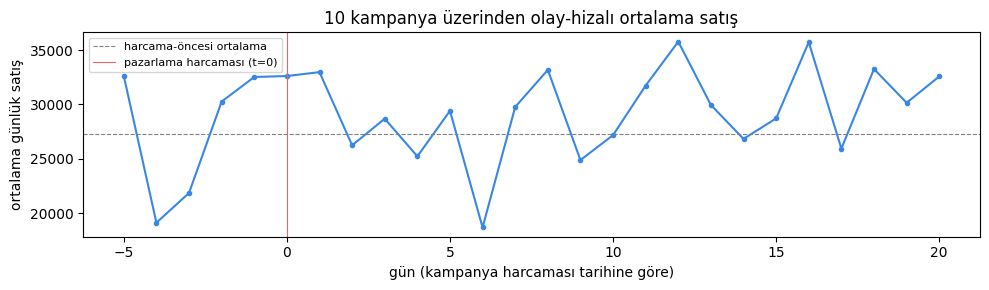

Harcama-öncesi baz seviye: 27274, en yüksek satış günü: t+12


In [5]:
spend_dates = pd.read_sql(text('''
    SELECT created_at::date AS spend_date FROM finance_transactions
    WHERE type='EXPENSE' AND description='Kampanya öncesi pazarlama harcaması'
    ORDER BY created_at
'''), db.bind)["spend_date"]

merged_naive = merged.copy()
merged_naive["day"] = pd.to_datetime(merged_naive["day"]).dt.tz_localize(None)
sales_by_day = merged_naive.set_index("day")["sales_total"]
window = range(-5, 21)
aligned = []
for spend_date in spend_dates:
    spend_date = pd.Timestamp(spend_date)
    row = [sales_by_day.get(spend_date + pd.Timedelta(days=d), np.nan) for d in window]
    aligned.append(row)

aligned = np.array(aligned, dtype=float)
avg_curve = np.nanmean(aligned, axis=0)
baseline = np.nanmean(avg_curve[:5])  # spend öncesi (t<0) ortalama = baz seviye

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(list(window), avg_curve, marker="o", markersize=3, color="#3987e5")
ax.axhline(baseline, color="gray", linestyle="--", linewidth=0.8, label="harcama-öncesi ortalama")
ax.axvline(0, color="#e66767", linewidth=0.8, label="pazarlama harcaması (t=0)")
ax.set_xlabel("gün (kampanya harcaması tarihine göre)")
ax.set_ylabel("ortalama günlük satış")
ax.set_title(f"{len(spend_dates)} kampanya üzerinden olay-hizalı ortalama satış")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("01_event_aligned.png", dpi=80)
plt.show()

peak_offset = list(window)[int(np.nanargmax(avg_curve))]
print(f"Harcama-öncesi baz seviye: {baseline:.0f}, en yüksek satış günü: t+{peak_offset}")


**Sonuç**: Olay-hizalı ortalama, `seed.py`'nin kampanya penceresini kasıtlı
olarak `t≈+5..+8` civarına yerleştirdiği bilgisiyle karşılaştırılabilir bir
zirve günü verir (yukarıdaki `en yüksek satış günü` çıktısına bakınız). Bu
iki yaklaşım birlikte önemli bir dersi gösteriyor: **whole-series çapraz
korelasyon az sayıda ayrık olayda yetersiz kalabilir; olay-hizalı ortalama
gibi hedefe özel yöntemler gerekebilir.** Yine de — tekrar vurgulanmalı —
**bu bir nedensellik kanıtı değildir**; kampanya takviminin kendisi hem
pazarlama harcamasını hem de satışı aynı anda etkileyen ortak bir faktördür
(confounder).

In [6]:
db.close()